In [1]:
#text-to-image
#https://huggingface.co/stabilityai/sdxl-turbo
from diffusers import AutoPipelineForText2Image
import torch

pipe = AutoPipelineForText2Image.from_pretrained("stabilityai/sdxl-turbo", torch_dtype=torch.float16, variant="fp16")
# pipe.to("cuda")

prompt = "A cinematic shot of a baby racoon wearing an intricate italian priest robe."

image = pipe(prompt=prompt, num_inference_steps=1, guidance_scale=0.0, device = 1).images[0]

`Siglip2ImageProcessorFast` is deprecated. The `Fast` suffix for image processors has been removed; use `Siglip2ImageProcessor` instead.
/home/nikita/anaconda3/envs/tf-gpu/lib/python3.10/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

/home/nikita/anaconda3/envs/tf-gpu/lib/python3.10/site-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


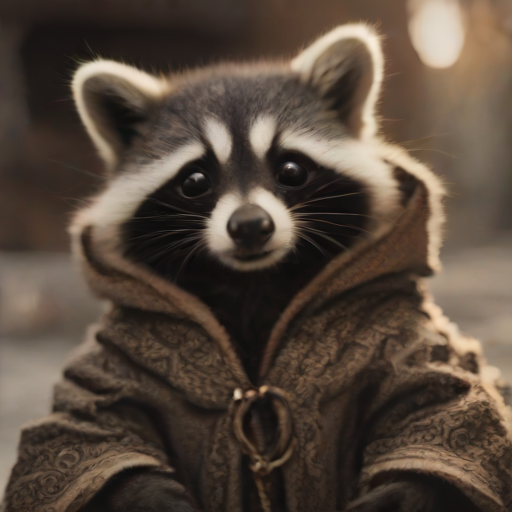

In [3]:
image

In [4]:
#image-to-text
#https://huggingface.co/Salesforce/blip-image-captioning-large

import requests
from PIL import Image
from transformers import BlipProcessor, BlipForConditionalGeneration

processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-large")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-large")

img_url = 'https://storage.googleapis.com/sfr-vision-language-research/BLIP/demo.jpg' 
raw_image = Image.open(requests.get(img_url, stream=True).raw).convert('RGB')

# conditional image captioning
text = "A dog"
inputs = processor(raw_image, text, return_tensors="pt")

out = model.generate(**inputs)
print(processor.decode(out[0], skip_special_tokens=True))

# unconditional image captioning
inputs = processor(raw_image, return_tensors="pt")

out = model.generate(**inputs)
print(processor.decode(out[0], skip_special_tokens=True))

Loading weights:   0%|          | 0/616 [00:00<?, ?it/s]

BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-large
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/home/nikita/anaconda3/envs/tf-gpu/lib/python3.10/site-packages/transformers/generation/utils.py:1569: UserWarning: Using the model-agnostic default `max_length` (=23) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


a dog sitting on the beach with a woman and a dog


/home/nikita/anaconda3/envs/tf-gpu/lib/python3.10/site-packages/transformers/generation/utils.py:1569: UserWarning: Using the model-agnostic default `max_length` (=21) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


woman sitting on the beach with her dog and a cell phone


In [35]:
#https://medium.com/@whyamit101/building-stable-diffusion-models-from-scratch-in-pytorch-a-complete-practical-guide-ffbbd5346c48
#https://www.geeksforgeeks.org/artificial-intelligence/diffusion-models-in-machine-learning/
#https://shunya-vichaar.medium.com/the-stable-diffusion-model-an-introductory-guide-efbfa0d5a8c5
#https://kailashahirwar.medium.com/a-very-short-introduction-to-diffusion-models-a84235e4e9ae

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.0+cu121
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [2]:
batch_size = 64
epochs = 100
lr = 1e-4
T = 100

beta = torch.linspace(1e-4, 0.02, T).to(device)
alpha = 1. - beta
alpha_hat = torch.cumprod(alpha, dim=0)

In [3]:
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = torch.exp(
            torch.arange(half_dim, device=device) * 
            -(np.log(10000) / (half_dim - 1))
        )
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

In [4]:
class Denoiser(nn.Module):
    def __init__(self):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(32),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 16)
        )

        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.conv3 = nn.Conv2d(32, 3, 3, padding=1)

    def forward(self, x, t):
        x = x.float()
        t = self.time_mlp(t)
        t = t[:, :, None, None]
        x = self.conv1(x)
        x = x + t
        x = F.relu(self.conv2(x))
        return self.conv3(x)

model = Denoiser().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=False, persistent_workers=False)

Files already downloaded and verified


In [6]:
def forward_diffusion(x0, t):
    noise = torch.randn_like(x0)
    sqrt_alpha_hat = torch.sqrt(alpha_hat[t])[:, None, None, None]
    sqrt_one_minus_alpha_hat = torch.sqrt(1 - alpha_hat[t])[:, None, None, None]
    return sqrt_alpha_hat * x0 + sqrt_one_minus_alpha_hat * noise, noise

In [7]:
for epoch in range(epochs):
    for images, _ in dataloader:
        images = images.to(device)
        t = torch.randint(0, T, (images.size(0),), device=device)

        xt, noise = forward_diffusion(images, t)

        predicted_noise = model(xt, t.float())
        loss = F.mse_loss(predicted_noise, noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    if (epoch+1)%10 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item()}")

print("Training completed!")

Epoch 10, Loss: 0.14581985771656036
Epoch 20, Loss: 0.1135479137301445
Epoch 30, Loss: 0.09845568239688873
Epoch 40, Loss: 0.20652902126312256
Epoch 50, Loss: 0.15676209330558777
Epoch 60, Loss: 0.20488601922988892
Epoch 70, Loss: 0.10631539672613144
Epoch 80, Loss: 0.15732385218143463
Epoch 90, Loss: 0.21439963579177856
Epoch 100, Loss: 0.13637958467006683
Training completed!


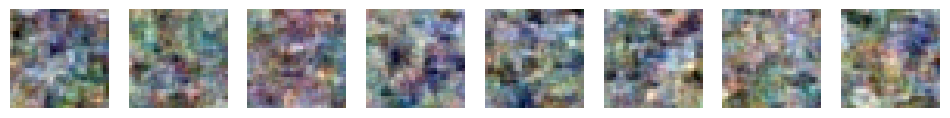

In [8]:
def sample(model, n):
    model.eval()
    x = torch.randn((n, 3, 32, 32)).to(device)

    for t in reversed(range(T)):
        t_tensor = torch.full((n,), t, device=device)
        predicted_noise = model(x, t_tensor.float())

        alpha_t = alpha[t]
        alpha_hat_t = alpha_hat[t]
        beta_t = beta[t]

        if t > 0:
            noise = torch.randn_like(x)
        else:
            noise = torch.zeros_like(x)

        x = (1 / torch.sqrt(alpha_t)) * (
            x - (1 - alpha_t) / torch.sqrt(1 - alpha_hat_t) * predicted_noise
        ) + torch.sqrt(beta_t) * noise

    return x

generated_images = sample(model, 8)
generated_images = (generated_images + 1) / 2
generated_images = generated_images.clamp(0,1).detach().cpu()

plt.figure(figsize=(12,4))
for i in range(8):
    plt.subplot(1,8,i+1)
    plt.imshow(generated_images[i].permute(1,2,0))
    plt.axis('off')
plt.show()

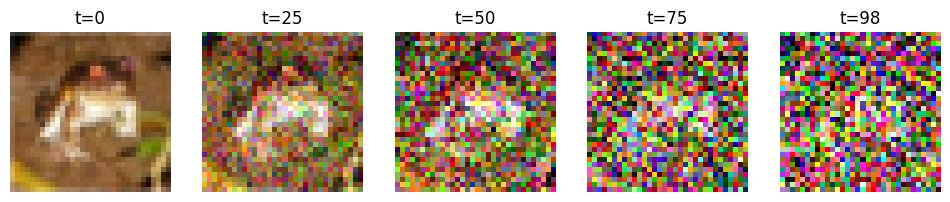

In [9]:
sample_img, _ = dataset[0]
sample_img = sample_img.unsqueeze(0).to(device)

plt.figure(figsize=(12,3))
for i, step in enumerate([0, 25, 50, 75, 98]):
    t = torch.tensor([step], device=device)
    xt, _ = forward_diffusion(sample_img, t)
    xt = (xt + 1) / 2
    xt = xt.clamp(0,1).cpu()
    plt.subplot(1,5,i+1)
    plt.imshow(xt[0].permute(1,2,0))
    plt.title(f"t={step}")
    plt.axis('off')
plt.show()

In [15]:
# import os
# os.environ['CUDA_LAUNCH_BLOCKING'] = '0'
# os.environ['TORCH_USE_CUDA_DSA'] = '0' 